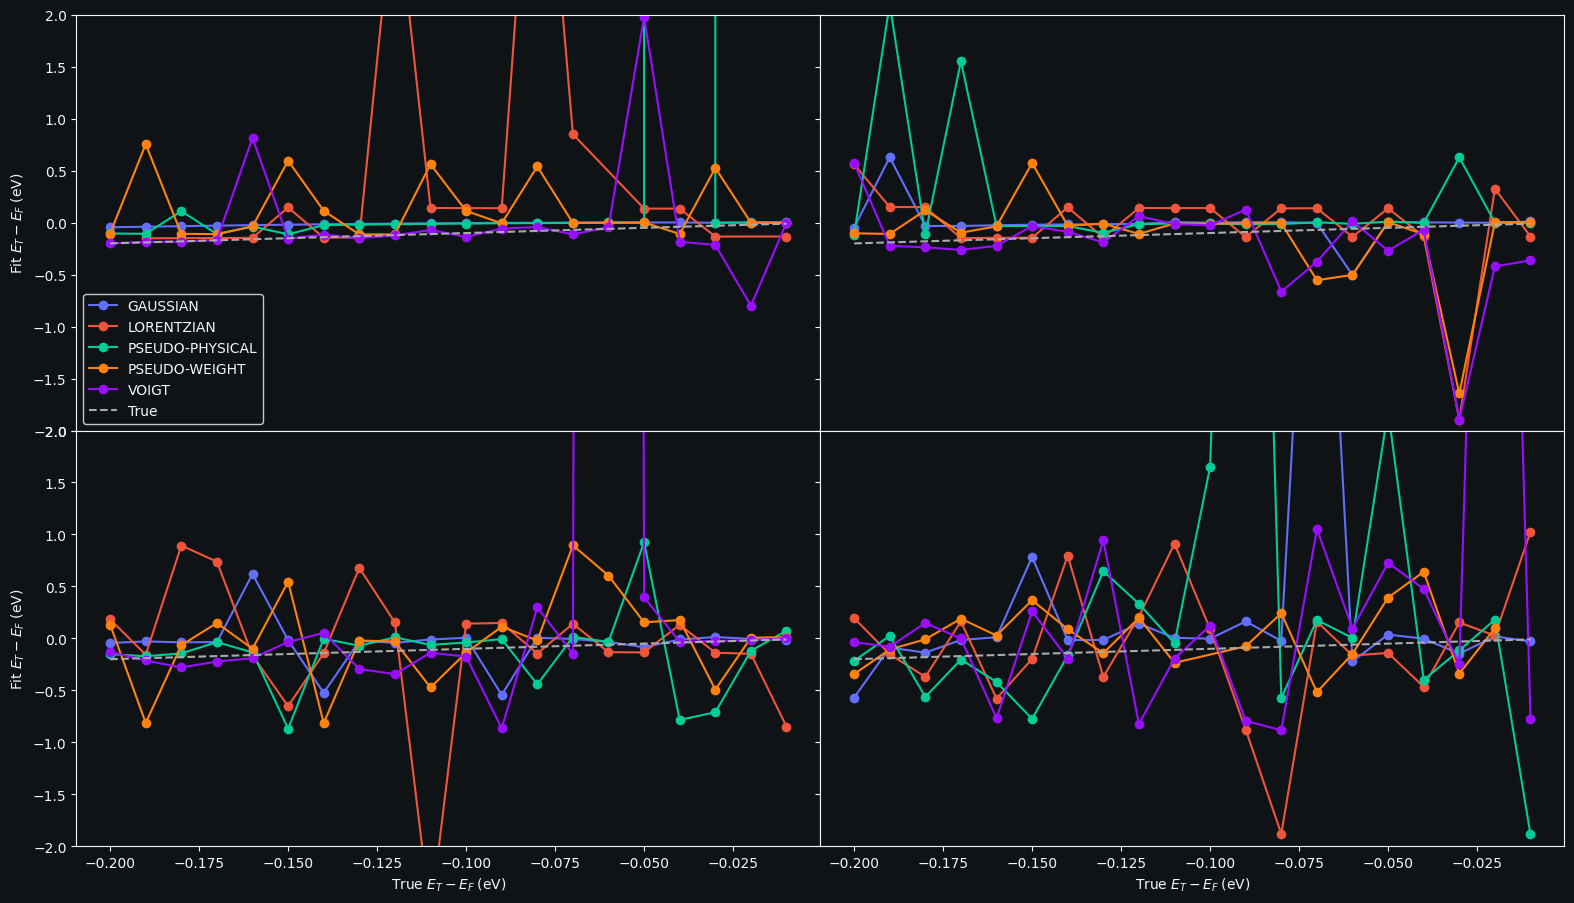

In [24]:
import pandas as pd
from PetrizzeTheme import petrizze_template
import matplotlib.pyplot as plt

petrizze_template()

df = pd.read_parquet("Out\\Data.parquet")

df["True_Exciton_Energy_Diff"] = df["True_exciton_T_energy"] - df["True_exciton_X_energy"]
df["Fit_Exciton_Energy_Diff"] = df["Fit_exciton_1_energy"] - df["Fit_exciton_0_energy"]
df["True_Fit_Exciton_Diff"] = df["Fit_Exciton_Energy_Diff"] - df["True_Exciton_Energy_Diff"]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(19.2, 10.8), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)
ax = ax.flatten()
for j, (noise_key, noise_data) in enumerate(df.groupby("NOISE_STD_VALUE")):
    for i, (lineshape_key, lineshape_data) in enumerate(noise_data.groupby("LINESHAPE_KEY")):
        
        Red_Chi2 = lineshape_data["RED_CHI2"]
        mask = (lineshape_data["RED_CHI2"] >= 0.9) & (lineshape_data["RED_CHI2"] <= 1.1)

        x = lineshape_data["True_Exciton_Energy_Diff"]
        y = lineshape_data["Fit_Exciton_Energy_Diff"]

        ax[j].plot(x, y, label=lineshape_key, marker='o')
    
    ax[j].plot(x, x, '--', label='True', color='#AAAAAA')
    # ax[j].set_title(f'{noise_key} noise std')
    ax[j].set_ylim(-2, 2)
    
ax[0].set_ylabel(r'$\mathrm{Fit}\; E_T - E_F\;(\mathrm{eV})$')
ax[2].set_ylabel(r'$\mathrm{Fit}\; E_T - E_F\;(\mathrm{eV})$')
ax[2].set_xlabel(r'$\mathrm{True}\; E_T - E_F\;(\mathrm{eV})$')
ax[3].set_xlabel(r'$\mathrm{True}\; E_T - E_F\;(\mathrm{eV})$')
ax[0].legend()
plt.savefig('Out\\Plots\\Fit Energy Difference vs True Energy Difference.png')